In [1]:
%pip install --upgrade "jax[cuda13]" diffrax

  Using cached diffrax-0.7.0-py3-none-any.whl.metadata (17 kB)
  Using cached jax-0.6.2-py3-none-any.whl.metadata (13 kB)
  Using cached jaxlib-0.6.2-cp310-cp310-win_amd64.whl.metadata (1.4 kB)
  Using cached ml_dtypes-0.6.0-cp310-cp310-win_amd64.whl.metadata (8.8 kB)
  Using cached numpy-2.2.6-cp310-cp310-win_amd64.whl.metadata (60 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached scipy-1.15.3-cp310-cp310-win_amd64.whl.metadata (60 kB)
  Using cached equinox-0.13.8-py3-none-any.whl.metadata (18 kB)
  Using cached jaxtyping-0.3.7-py3-none-any.whl.metadata (7.3 kB)
  Using cached lineax-0.1.0-py3-none-any.whl.metadata (18 kB)
  Using cached optimistix-0.0.11-py3-none-any.whl.metadata (18 kB)
  Using cached wadler_lindig-0.1.7-py3-none-any.whl.metadata (17 kB)
Using cached jax-0.6.2-py3-none-any.whl (2.7 MB)
Using cached jaxlib-0.6.2-cp310-cp310-win_amd64.whl (57.9 MB)
Using cached diffrax-0.7.0-py3-none-any.whl (193 kB)
Using cached equinox-0.13.8-py3

$$\begin{aligned}
\frac{dx}{dt} &= \alpha x - \beta x y \\[1.5ex]
\frac{dy}{dt} &= \delta x y - \gamma y
\end{aligned}$$

x
 = prey population

y
 = predator population

α
 = prey growth rate

β
 = predation rate

δ
 = predator reproduction rate

γ
 = predator death rate

# Using GPU

In [3]:
import jax
import jax.numpy as jnp
import diffrax
import equinox as eqx
import lineax as lx
import optimistix as optx
import matplotlib.pyplot as plt
import numpy as np

In [4]:
# 1. Define the ODE vector field
def lotka_volterra(t, y, args):
    """
    y: array [x, y] (states)
    args: array [alpha, beta, gamma, delta] (parameters)
    """
    x, y_state = y
    alpha, beta, gamma, delta = args
    
    dxdt = alpha * x - beta * x * y_state
    dydt = delta * x * y_state - gamma * y_state
    
    return jnp.stack([dxdt, dydt])

In [5]:
# 2. Define a single ODE evaluation wrapped in a function
@jax.jit
def run_batch(batch_params, y0):
    def solve_single_ode(params):
        term = diffrax.ODETerm(lotka_volterra)
        # solver = diffrax.Tsit5()

        # BDF solver (Defaults to internal Newton-Raphson iteration)
        solver = diffrax.Kvaerno5()
        # saveat = diffrax.SaveAt(ts=ts)
        
        solution = diffrax.diffeqsolve(
            term,
            solver,
            t0=0, #t0,
            t1=15, #t1,
            dt0=0.01,
            y0=y0,
            args=params,
            saveat=diffrax.SaveAt(ts=jnp.linspace(0.0, 15.0, 1000)), #saveat,
            stepsize_controller=diffrax.PIDController(rtol=1e-3, atol=1e-6),
            # stepsize_controller=diffrax.ConstantStepSize(),
            max_steps=65536
        )
        return solution.ys
    return jax.vmap(solve_single_ode)(batch_params)

In [ ]:
# def solve_single_ode(params, y0, t0, t1, saveat):
#     term = diffrax.ODETerm(lotka_volterra)
#     # solver = diffrax.Tsit5()

#     # BDF solver (Defaults to internal Newton-Raphson iteration)
#     solver = diffrax.Kvaerno5()
#     # saveat = diffrax.SaveAt(ts=ts)
    
#     solution = diffrax.diffeqsolve(
#         term,
#         solver,
#         t0=0, #t0,
#         t1=15, #t1,
#         dt0=0.01,
#         y0=y0,
#         args=params,
#         saveat=diffrax.SaveAt(ts=jnp.linspace(0.0, 15.0, 1000)), #saveat,
#         stepsize_controller=diffrax.PIDController(rtol=1e-3, atol=1e-6),
#         max_steps=65536
#     )
#     return solution.ys

In [ ]:
# # 3. Vectorize over parameter sets using jax.vmap
# # in_axes=(0, None, None, None, None) maps over the 0-th axis of `params`
# # while holding initial conditions and time boundaries fixed.
# solve_batch = jax.vmap(solve_single_ode, in_axes=(0, None, None, None, None))

# # 4. JIT-compile the vectorized solver for GPU execution
# solve_batch_ode_jit = eqx.filter_jit(solve_batch)

In [6]:
# Create 10,000 parameter combinations
num_simulations = 200
key = jax.random.PRNGKey(42)

In [7]:
# Generate random parameters (alpha, beta, gamma, delta) centered around default values
param_defaults = jnp.array([1.5, 1.0, 3.0, 1.0])
param_variations = jax.random.uniform(key, shape=(num_simulations, 4), minval=0.8, maxval=1.2)
batch_params = param_defaults * param_variations  # Shape: (10000, 4)

In [8]:
# Fixed simulation setup
param_defaults = jnp.array([1.5, 1.0, 3.0, 1.0])
param_variations = jax.random.uniform(key, shape=(num_simulations, 4), minval=0.8, maxval=1.2)
batch_params = param_defaults * param_variations  # Save 100 time points per simulation

In [9]:
y0 = jnp.array([10.0, 5.0])
t0, t1 = 0.0, 15.0
saveat = diffrax.SaveAt(ts=jnp.linspace(t0, t1, 1000))

In [10]:
ts = jnp.linspace(0.0, 15.0, 1000)

In [12]:
_ = run_batch(batch_params[:10], y0)

In [14]:
results = run_batch(batch_params, y0) # 200 takes 0.5 s

In [15]:
num_simulations = 200
key = jax.random.PRNGKey(42)

param_defaults = jnp.array([1.5, 1.0, 3.0, 1.0])
param_variations = jax.numpy.ones(shape=(num_simulations, 4), dtype=None, device=None)
batch_params = param_defaults * param_variations  # Shape: (10000, 4)

results2 = run_batch(batch_params, y0)

In [16]:
num_simulations = 2000
key = jax.random.PRNGKey(42)

param_defaults = jnp.array([1.5, 1.0, 3.0, 1.0])
param_variations = jax.numpy.ones(shape=(num_simulations, 4), dtype=None, device=None)
batch_params = param_defaults * param_variations  # Shape: (10000, 4)

results2 = run_batch(batch_params, y0) # 2000 is 4.6 s

In [ ]:
num_simulations = 8000
key = jax.random.PRNGKey(42)

param_defaults = jnp.array([1.5, 1.0, 3.0, 1.0])
param_variations = jax.numpy.ones(shape=(num_simulations, 4), dtype=None, device=None)
batch_params = param_defaults * param_variations  # Shape: (10000, 4)

results2 = run_batch(batch_params, y0) # 8000 is 9.8 s

In [ ]:
# # Warmup run (triggers XLA compilation)
# _ = solve_batch_ode_jit(batch_params[:10], y0, t0, t1, saveat)

In [ ]:
# # Perform GPU-accelerated parallel batch execution
# print(f"Simulating {num_simulations} ODEs on GPU...")
# results = solve_batch_ode_jit(batch_params, y0, t0, t1, saveat)
# print("Results shape:", results.shape)  # (10000, 100, 2)

Simulating 2000 ODEs on GPU...


In [23]:
# Output shape: (num_simulations, num_time_points, num_states)
print("Results shape:", results.shape)  # Should be (10000, 100, 2)

Results shape: (200, 1000, 2)


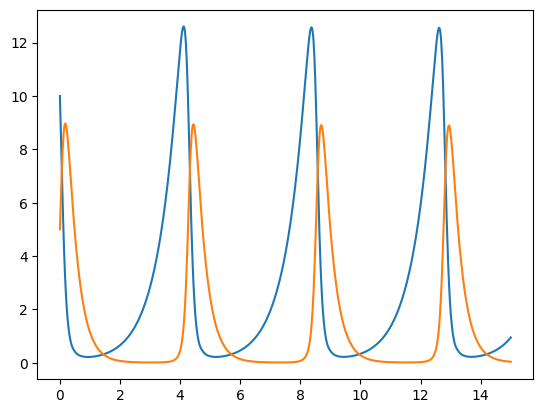

In [24]:
plt.plot(ts, results[0,::,0])
plt.plot(ts, results[0,::,1])

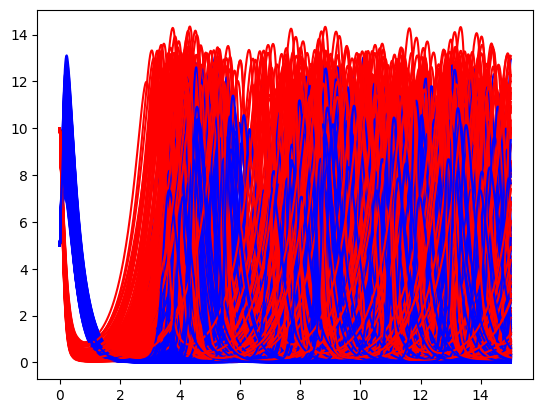

In [25]:
plt.figure()
for i in range(np.shape(results)[0]):
    plt.plot(ts, results[i,::,0], c='r')
    plt.plot(ts, results[i,::,1], c='b')
plt.show()

# Using CPU

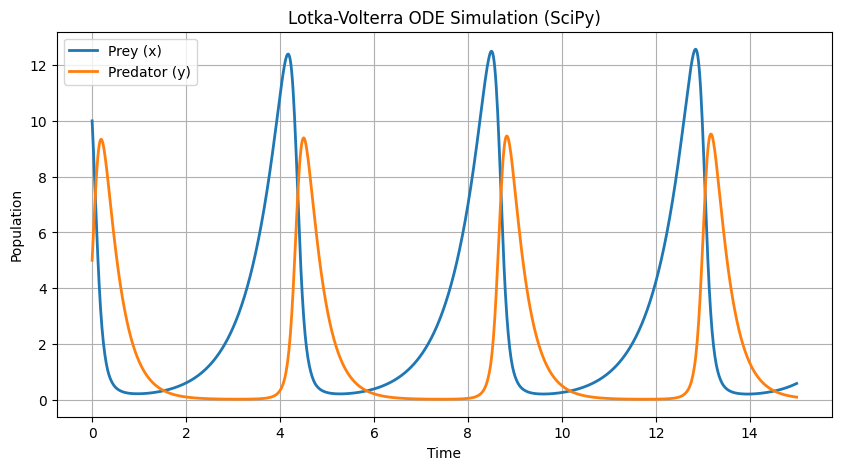

In [23]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# 1. Define the system of differential equations
def lotka_volterra(t, z, alpha, beta, gamma, delta):
    x, y = z
    dxdt = alpha * x - beta * x * y
    dydt = delta * x * y - gamma * y
    return [dxdt, dydt]

# 2. Parameters and Initial Conditions
params = (1.5, 1.0, 3.0, 1.0)  # alpha, beta, gamma, delta
y0 = [10.0, 5.0]                # initial populations [prey, predator]
t_span = (0.0, 15.0)            # start and end time
t_eval = np.linspace(0.0, 15.0, 1000) # time points to evaluate

# 3. Solve the ODE
sol = solve_ivp(
    fun=lotka_volterra,
    t_span=t_span,
    y0=y0,
    t_eval=t_eval,
    args=params,
    method='RK45'  # Use 'Radau' or 'BDF' if the system is stiff
)

# 4. Plot the results
plt.figure(figsize=(10, 5))
plt.plot(sol.t, sol.y[0], label='Prey (x)', linewidth=2)
plt.plot(sol.t, sol.y[1], label='Predator (y)', linewidth=2)
plt.xlabel('Time')
plt.ylabel('Population')
plt.title('Lotka-Volterra ODE Simulation (SciPy)')
plt.legend()
plt.grid(True)
plt.show()

In [27]:
# 200 is 1.8 s
# 2000 is 18.1 s (4.6 in GPU)
for i in range(2000):
    sol = solve_ivp(
        fun=lotka_volterra,
        t_span=t_span,
        y0=y0,
        t_eval=t_eval,
        args=params,
        method='RK45'  # Use 'Radau' or 'BDF' if the system is stiff
    )